# DeMemte Variants Benchmark (Objetivo: eliminar trade-off clean vs noisy)

Este notebook implementa y compara:
- Baseline ResNet18 puro
- DeMemte 1D VQ-VAE (post-pooling)
- DeMemte Spatial Transformer VQ-VAE
- DeMemte Spatial Conv2d VQ-VAE con Masked Feature Modeling

Meta: mantener/mejorar accuracy clean y aumentar el gap positivo en escenarios con ruido/corrupción.

In [ ]:
import os
import copy
import json
import random
from dataclasses import dataclass, asdict
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, Subset

import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import StratifiedShuffleSplit

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('cuda:', torch.cuda.is_available())

In [ ]:
@dataclass
class Config:
    data_dir: str = '../data'
    num_classes: int = 102
    batch_size: int = 64
    num_workers: int = 2

    val_ratio: float = 0.2
    split_seed: int = 42

    lr_baseline: float = 1e-3
    lr_vq: float = 3e-4
    lr_cls: float = 1e-4
    weight_decay: float = 1e-4

    epochs_baseline_max: int = 16
    epochs_phase1_max: int = 8
    epochs_phase2_max: int = 18

    early_stop_patience: int = 3
    early_stop_min_delta: float = 1e-4

    scheduler_factor: float = 0.5
    scheduler_patience: int = 1

    # Memory capacity (no afecta al baseline puro)
    embedding_dim: int = 256
    num_embeddings: int = 1024
    commitment_cost: float = 0.25

    # Router: más proclive a usar memoria ante ruido moderado
    init_tau: float = 1.0
    init_alpha: float = 1.5

    # Mayor presión de reconstrucción para robustez
    denoise_weight: float = 0.5
    vq_weight: float = 0.25

    # Variant-specific
    attn_heads: int = 4
    attn_layers: int = 2
    masked_feature_ratio: float = 0.35

    train_corrupt_prob: float = 0.7

    max_train_batches_debug: int = 10000000
    max_val_batches_debug: int = 10000000

    variant_names_override: list | None = None

    artifacts_root: str = './out/artifacts'
    experiment_name: str = 'dememte_variants_fastsplit'

    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'

cfg = Config()
device = torch.device(cfg.device)
criterion = nn.CrossEntropyLoss()
print(json.dumps(asdict(cfg), indent=2))

In [ ]:
def _extract_labels(dataset):
    if hasattr(dataset, '_labels'):
        return np.array(dataset._labels)
    if hasattr(dataset, 'labels'):
        return np.array(dataset.labels)
    ys = []
    for i in range(len(dataset)):
        _, y = dataset[i]
        ys.append(int(y))
    return np.array(ys)

def build_datasets(config: Config):
    transform_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    transform_eval = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    tr = torchvision.datasets.Flowers102(root=config.data_dir, split='train', download=False, transform=transform_train)
    va = torchvision.datasets.Flowers102(root=config.data_dir, split='val', download=False, transform=transform_train)
    te = torchvision.datasets.Flowers102(root=config.data_dir, split='test', download=False, transform=transform_eval)

    cv_ds = ConcatDataset([tr, va])
    cv_y = np.concatenate([_extract_labels(tr), _extract_labels(va)], axis=0)

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=config.val_ratio, random_state=config.split_seed)
    train_idx, val_idx = next(splitter.split(np.zeros(len(cv_y)), cv_y))

    tr_ds = Subset(cv_ds, train_idx.tolist())
    va_ds = Subset(cv_ds, val_idx.tolist())

    tr_loader = DataLoader(tr_ds, batch_size=config.batch_size, shuffle=True, num_workers=config.num_workers, pin_memory=True)
    va_loader = DataLoader(va_ds, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)
    te_loader = DataLoader(te, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)

    return tr_loader, va_loader, te_loader

trainloader, valloader, testloader = build_datasets(cfg)
print('train batches:', len(trainloader), '| val batches:', len(valloader), '| test batches:', len(testloader))

In [ ]:
def make_backbone():
    base = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    return nn.Sequential(*list(base.children())[:-2])

class ResNetPureBaseline(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x, return_debug=False):
        feats = self.backbone(x)
        feats_flat = self.pool(feats).flatten(1)
        logits = self.classifier(feats_flat)
        if return_debug:
            return logits, {'clean_feats': feats, 'enhanced_feats': feats}
        return logits

class VectorQuantizer2D(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / num_embeddings, 1 / num_embeddings)

    def forward(self, z_e):
        b, c, h, w = z_e.shape
        z_e_perm = z_e.permute(0, 2, 3, 1).contiguous()
        flat = z_e_perm.view(-1, c)
        emb = self.embedding.weight
        distances = flat.pow(2).sum(1, keepdim=True) - 2 * flat @ emb.t() + emb.pow(2).sum(1, keepdim=True).t()
        idx = torch.argmin(distances, dim=1)
        one_hot = F.one_hot(idx, self.num_embeddings).type(flat.dtype)
        q_flat = one_hot @ emb
        q = q_flat.view(b, h, w, c).permute(0, 3, 1, 2).contiguous()
        vq_loss = self.commitment_cost * F.mse_loss(z_e, q.detach()) + F.mse_loss(q, z_e.detach())
        q_st = z_e + (q - z_e).detach()
        dq_map = ((z_e - q.detach()) ** 2).mean(dim=1, keepdim=True)
        return q_st, vq_loss, dq_map

class VectorQuantizer1D(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / num_embeddings, 1 / num_embeddings)

    def forward(self, z_e):
        emb = self.embedding.weight
        distances = z_e.pow(2).sum(1, keepdim=True) - 2 * z_e @ emb.t() + emb.pow(2).sum(1, keepdim=True).t()
        idx = torch.argmin(distances, dim=1)
        one_hot = F.one_hot(idx, self.num_embeddings).type(z_e.dtype)
        q = one_hot @ emb
        vq_loss = self.commitment_cost * F.mse_loss(z_e, q.detach()) + F.mse_loss(q, z_e.detach())
        q_st = z_e + (q - z_e).detach()
        dq = ((z_e - q.detach()) ** 2).mean(dim=1, keepdim=True)
        return q_st, vq_loss, dq

class SpatialConvVQVAE(nn.Module):
    def __init__(self, in_channels=512, hidden_channels=256, embedding_dim=128, num_embeddings=512, commitment_cost=0.25):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, 3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, embedding_dim, 1),
        )
        self.vq = VectorQuantizer2D(num_embeddings, embedding_dim, commitment_cost)
        self.decoder = nn.Sequential(
            nn.Conv2d(embedding_dim, hidden_channels, 3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, in_channels, 1),
        )

    def forward(self, x):
        z = self.encoder(x)
        zq, vq_loss, dq_map = self.vq(z)
        x_rec = self.decoder(zq)
        return x_rec, vq_loss, dq_map

class AttentionSpatialVQVAE(nn.Module):
    def __init__(self, in_channels=512, hidden_channels=256, embedding_dim=128, num_embeddings=512, commitment_cost=0.25, heads=4, layers=1):
        super().__init__()
        self.pre = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, 1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, embedding_dim, 1),
        )
        self.pos_embed = nn.Parameter(torch.zeros(1, embedding_dim, 7, 7))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        self.attn_blocks = nn.ModuleList([
            nn.MultiheadAttention(embed_dim=embedding_dim, num_heads=heads, batch_first=True) for _ in range(layers)
        ])
        self.attn_norms = nn.ModuleList([nn.LayerNorm(embedding_dim) for _ in range(layers)])
        self.ffn_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(embedding_dim, embedding_dim * 4),
                nn.GELU(),
                nn.Linear(embedding_dim * 4, embedding_dim),
            ) for _ in range(layers)
        ])
        self.ffn_norms = nn.ModuleList([nn.LayerNorm(embedding_dim) for _ in range(layers)])

        self.vq = VectorQuantizer2D(num_embeddings, embedding_dim, commitment_cost)
        self.post = nn.Sequential(
            nn.Conv2d(embedding_dim, hidden_channels, 1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, in_channels, 1),
        )

    def _run_attn(self, z):
        b, c, h, w = z.shape
        pos = self.pos_embed
        if pos.shape[-2:] != (h, w):
            pos = F.interpolate(pos, size=(h, w), mode='bilinear', align_corners=False)
        z = z + pos

        toks = z.flatten(2).transpose(1, 2)
        for attn, attn_norm, ffn, ffn_norm in zip(self.attn_blocks, self.attn_norms, self.ffn_blocks, self.ffn_norms):
            out, _ = attn(toks, toks, toks, need_weights=False)
            toks = attn_norm(toks + out)
            ff = ffn(toks)
            toks = ffn_norm(toks + ff)

        z2 = toks.transpose(1, 2).view(b, c, h, w)
        return z2

    def forward(self, x):
        z = self.pre(x)
        z = self._run_attn(z)
        zq, vq_loss, dq_map = self.vq(z)
        x_rec = self.post(zq)
        return x_rec, vq_loss, dq_map

class OneDVQVAE(nn.Module):
    def __init__(self, in_dim=512, hidden_dim=256, embedding_dim=128, num_embeddings=512, commitment_cost=0.25):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, embedding_dim),
        )
        self.vq = VectorQuantizer1D(num_embeddings, embedding_dim, commitment_cost)
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, in_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        zq, vq_loss, dq = self.vq(z)
        x_rec = self.decoder(zq)
        dq_map = dq.view(-1, 1, 1, 1)
        return x_rec, vq_loss, dq_map

class DeMemteSpatial(nn.Module):
    def __init__(self, backbone, vq_vae, num_classes):
        super().__init__()
        self.backbone = backbone
        self.vq_vae = vq_vae
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(512, num_classes)
        self.gate_tau = nn.Parameter(torch.tensor(0.0))
        self.gate_alpha = nn.Parameter(torch.tensor(1.5))
        self.register_buffer('dq_ema_mean', torch.tensor(0.0))
        self.register_buffer('dq_ema_var', torch.tensor(1.0))
        self.register_buffer('dq_ema_counted', torch.tensor(0.0))

    def set_backbone_trainable(self, trainable: bool):
        for p in self.backbone.parameters():
            p.requires_grad = trainable

    def _update_ema(self, dq_map):
        with torch.no_grad():
            batch_mean = dq_map.mean()
            batch_var = dq_map.var(unbiased=False) if dq_map.numel() > 1 else torch.tensor(0.0, device=dq_map.device)
            momentum = 0.99
            if self.dq_ema_counted.item() == 0:
                self.dq_ema_mean.fill_(batch_mean)
                self.dq_ema_var.fill_(batch_var)
            else:
                self.dq_ema_mean.mul_(momentum).add_(batch_mean * (1 - momentum))
                self.dq_ema_var.mul_(momentum).add_(batch_var * (1 - momentum))
            self.dq_ema_counted.add_(1.0)

    def _mask_features(self, feats, mask_ratio):
        if mask_ratio <= 0:
            return feats
        b, _, h, w = feats.shape
        keep = (torch.rand(b, 1, h, w, device=feats.device) > mask_ratio).float()
        return feats * keep

    def forward(self, x, target_feats=None, update_ema=True, return_debug=False, feature_mask_ratio=0.0):
        input_feats = self.backbone(x)
        vq_input = self._mask_features(input_feats, feature_mask_ratio if self.training else 0.0)
        rec_feats, vq_loss, dq_map = self.vq_vae(vq_input)

        target = input_feats.detach() if target_feats is None else target_feats.detach()
        denoise_loss = F.mse_loss(rec_feats, target)

        if self.training and update_ema:
            self._update_ema(dq_map)

        dq_norm = (dq_map - self.dq_ema_mean) / (torch.sqrt(self.dq_ema_var) + 1e-5)
        alpha = F.softplus(self.gate_alpha)
        signal = torch.sigmoid(alpha * (dq_norm - self.gate_tau))
        enhanced = (1.0 - signal) * input_feats + signal * rec_feats

        logits = self.classifier(self.pool(enhanced).flatten(1))
        if return_debug:
            return logits, denoise_loss, vq_loss, {'clean_feats': input_feats, 'enhanced_feats': enhanced, 'signal': signal}
        return logits, denoise_loss, vq_loss

class DeMemte1D(nn.Module):
    def __init__(self, backbone, vq_vae_1d, num_classes):
        super().__init__()
        self.backbone = backbone
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.vq_vae = vq_vae_1d
        self.classifier = nn.Linear(512, num_classes)
        self.gate_tau = nn.Parameter(torch.tensor(0.0))
        self.gate_alpha = nn.Parameter(torch.tensor(1.5))
        self.register_buffer('dq_ema_mean', torch.tensor(0.0))
        self.register_buffer('dq_ema_var', torch.tensor(1.0))
        self.register_buffer('dq_ema_counted', torch.tensor(0.0))

    def set_backbone_trainable(self, trainable: bool):
        for p in self.backbone.parameters():
            p.requires_grad = trainable

    def _update_ema(self, dq_map):
        with torch.no_grad():
            batch_mean = dq_map.mean()
            batch_var = dq_map.var(unbiased=False) if dq_map.numel() > 1 else torch.tensor(0.0, device=dq_map.device)
            momentum = 0.99
            if self.dq_ema_counted.item() == 0:
                self.dq_ema_mean.fill_(batch_mean)
                self.dq_ema_var.fill_(batch_var)
            else:
                self.dq_ema_mean.mul_(momentum).add_(batch_mean * (1 - momentum))
                self.dq_ema_var.mul_(momentum).add_(batch_var * (1 - momentum))
            self.dq_ema_counted.add_(1.0)

    def forward(self, x, target_feats=None, update_ema=True, return_debug=False, feature_mask_ratio=0.0):
        feats = self.backbone(x)
        pooled = self.pool(feats).flatten(1)
        vq_input = pooled
        if self.training and feature_mask_ratio > 0:
            keep = (torch.rand_like(vq_input) > feature_mask_ratio).float()
            vq_input = vq_input * keep

        rec_vec, vq_loss, dq_map = self.vq_vae(vq_input)
        target = pooled.detach() if target_feats is None else target_feats.detach()
        denoise_loss = F.mse_loss(rec_vec, target)

        if self.training and update_ema:
            self._update_ema(dq_map)

        dq_norm = (dq_map - self.dq_ema_mean) / (torch.sqrt(self.dq_ema_var) + 1e-5)
        alpha = F.softplus(self.gate_alpha)
        signal = torch.sigmoid(alpha * (dq_norm - self.gate_tau)).flatten(1)
        enhanced_vec = (1.0 - signal) * pooled + signal * rec_vec

        logits = self.classifier(enhanced_vec)
        if return_debug:
            enhanced_feats = enhanced_vec.view(enhanced_vec.size(0), enhanced_vec.size(1), 1, 1)
            clean_feats = pooled.view(pooled.size(0), pooled.size(1), 1, 1)
            return logits, denoise_loss, vq_loss, {'clean_feats': clean_feats, 'enhanced_feats': enhanced_feats, 'signal': signal}
        return logits, denoise_loss, vq_loss

In [ ]:
def make_baseline(config: Config):
    model = ResNetPureBaseline(make_backbone(), config.num_classes).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=config.lr_baseline, weight_decay=config.weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=config.scheduler_factor, patience=config.scheduler_patience)
    return model, optimizer, scheduler

def make_variant(config: Config, variant_name: str):
    backbone = make_backbone()

    if variant_name == 'dememte_1d':
        model = DeMemte1D(
            backbone,
            OneDVQVAE(
                in_dim=512,
                hidden_dim=256,
                embedding_dim=config.embedding_dim,
                num_embeddings=config.num_embeddings,
                commitment_cost=config.commitment_cost,
            ),
            config.num_classes,
        ).to(device)
    elif variant_name == 'dememte_transformer':
        model = DeMemteSpatial(
            backbone,
            AttentionSpatialVQVAE(
                in_channels=512,
                hidden_channels=256,
                embedding_dim=config.embedding_dim,
                num_embeddings=config.num_embeddings,
                commitment_cost=config.commitment_cost,
                heads=config.attn_heads,
                layers=config.attn_layers,
            ),
            config.num_classes,
        ).to(device)
    elif variant_name == 'dememte_masked_conv':
        model = DeMemteSpatial(
            backbone,
            SpatialConvVQVAE(
                in_channels=512,
                hidden_channels=256,
                embedding_dim=config.embedding_dim,
                num_embeddings=config.num_embeddings,
                commitment_cost=config.commitment_cost,
            ),
            config.num_classes,
        ).to(device)
    else:
        raise ValueError(f'Variante no soportada: {variant_name}')

    model.gate_tau.data.fill_(config.init_tau)
    model.gate_alpha.data.fill_(config.init_alpha)

    vq_params = list(model.vq_vae.parameters())
    cls_params = [model.gate_tau, model.gate_alpha, model.classifier.weight, model.classifier.bias]

    model.set_backbone_trainable(False)

    optimizer_p1 = optim.AdamW(vq_params, lr=config.lr_vq, weight_decay=config.weight_decay)
    scheduler_p1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_p1, mode='min', factor=config.scheduler_factor, patience=config.scheduler_patience)

    optimizer_p2 = optim.AdamW([
        {'params': vq_params, 'lr': config.lr_vq},
        {'params': cls_params, 'lr': config.lr_cls},
    ], weight_decay=config.weight_decay)
    scheduler_p2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_p2, mode='max', factor=config.scheduler_factor, patience=config.scheduler_patience)

    return model, optimizer_p1, scheduler_p1, optimizer_p2, scheduler_p2

def warmstart_from_baseline(baseline_model, variant_model):
    variant_model.backbone.load_state_dict(copy.deepcopy(baseline_model.backbone.state_dict()))
    variant_model.classifier.load_state_dict(copy.deepcopy(baseline_model.classifier.state_dict()))

def apply_train_corruption(x):
    if random.random() > cfg.train_corrupt_prob:
        return x

    mode = random.choice(['gaussian_noise', 'pixel_mask', 'cutout', 'blur'])

    if mode == 'gaussian_noise':
        level = random.uniform(0.4, 1.3)
        return x + level * torch.randn_like(x)

    if mode == 'pixel_mask':
        level = random.uniform(0.20, 0.65)
        keep = (torch.rand(x.size(0), 1, x.size(2), x.size(3), device=x.device) > level).float()
        return x * keep

    if mode == 'cutout':
        level = random.uniform(0.20, 0.45)
        b, _, h, w = x.shape
        cut_h = max(1, int(h * level))
        cut_w = max(1, int(w * level))
        mask = torch.ones((b, 1, h, w), device=x.device, dtype=x.dtype)
        for i in range(b):
            t = random.randint(0, max(0, h - cut_h))
            l = random.randint(0, max(0, w - cut_w))
            mask[i, :, t:t + cut_h, l:l + cut_w] = 0.0
        return x * mask

    level = random.uniform(0.30, 0.80)
    channels = x.size(1)
    kernel_size = 7
    weight = torch.ones(channels, 1, kernel_size, kernel_size, device=x.device, dtype=x.dtype) / (kernel_size * kernel_size)
    blur = F.conv2d(x, weight, padding=kernel_size // 2, groups=channels)
    return (1.0 - level) * x + level * blur

def run_epoch_baseline(model, loader, optimizer, train):
    model.train(train)
    totals = {'loss': 0.0, 'acc': 0.0, 'n': 0}

    for bi, (x, y) in enumerate(loader):
        if train and bi >= cfg.max_train_batches_debug:
            break
        if (not train) and bi >= cfg.max_val_batches_debug:
            break

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        if train:
            # Equidad de Datos: El baseline ahora también estudia con ruido probabilístico
            x = apply_train_corruption(x)
            optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        acc = (logits.argmax(1) == y).float().mean().item()
        totals['loss'] += loss.item() * bs
        totals['acc'] += acc * bs
        totals['n'] += bs

    totals['loss'] /= max(1, totals['n'])
    totals['acc'] /= max(1, totals['n'])
    return totals

def run_epoch_variant_p1(model, loader, optimizer, train, variant_name):
    model.train(train)
    model.set_backbone_trainable(False)
    totals = {'loss': 0.0, 'n': 0}

    for bi, (x, _) in enumerate(loader):
        if train and bi >= cfg.max_train_batches_debug:
            break
        if (not train) and bi >= cfg.max_val_batches_debug:
            break

        x = x.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        feat_mask = cfg.masked_feature_ratio if variant_name in ('dememte_masked_conv', 'dememte_transformer') else 0.0
        _, denoise_loss, vq_loss = model(x, feature_mask_ratio=feat_mask)
        loss = cfg.denoise_weight * denoise_loss + cfg.vq_weight * vq_loss

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        totals['loss'] += loss.item() * bs
        totals['n'] += bs

    totals['loss'] /= max(1, totals['n'])
    return totals

def run_epoch_variant_p2(model, loader, optimizer, train, variant_name):
    model.train(train)
    model.set_backbone_trainable(False)

    totals = {'loss': 0.0, 'acc': 0.0, 'n': 0}

    for bi, (x, y) in enumerate(loader):
        if train and bi >= cfg.max_train_batches_debug:
            break
        if (not train) and bi >= cfg.max_val_batches_debug:
            break

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        x_clean = x
        x_noisy = apply_train_corruption(x.clone()) if train else x

        if train:
            optimizer.zero_grad(set_to_none=True)

        feat_mask = cfg.masked_feature_ratio if variant_name in ('dememte_masked_conv', 'dememte_transformer') else 0.0
        logits_clean, denoise_clean, vq_clean, dbg_clean = model(x_clean, target_feats=None, update_ema=True, return_debug=True, feature_mask_ratio=feat_mask)
        ce_clean = criterion(logits_clean, y)

        clean_target_feats = dbg_clean['clean_feats'].detach()
        if clean_target_feats.dim() > 2:
            clean_target_feats = clean_target_feats.flatten(1) if variant_name == 'dememte_1d' else clean_target_feats

        logits_noisy, denoise_noisy, vq_noisy = model(x_noisy, target_feats=clean_target_feats, update_ema=False, feature_mask_ratio=feat_mask)
        ce_noisy = criterion(logits_noisy, y)

        cls_loss = 0.5 * (ce_clean + ce_noisy)
        denoise_loss = 0.5 * (denoise_clean + denoise_noisy)
        vq_loss = 0.5 * (vq_clean + vq_noisy)
        loss = cls_loss + cfg.denoise_weight * denoise_loss + cfg.vq_weight * vq_loss

        if train:
            loss.backward()
            optimizer.step()

        bs = x.size(0)
        acc_clean = (logits_clean.argmax(1) == y).float().mean().item()
        acc_noisy = (logits_noisy.argmax(1) == y).float().mean().item()
        totals['loss'] += loss.item() * bs
        totals['acc'] += (0.5 * (acc_clean + acc_noisy)) * bs
        totals['n'] += bs

    totals['loss'] /= max(1, totals['n'])
    totals['acc'] /= max(1, totals['n'])
    return totals

def eval_clean_acc(model, loader, max_batches=10000000):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for bi, (x, y) in enumerate(loader):
            if bi >= max_batches:
                break
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            if isinstance(model, ResNetPureBaseline):
                logits = model(x)
            else:
                logits, _, _ = model(x)

            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)

    return correct / max(1, total)

In [ ]:
# Quick run overrides (baseline + todas las variantes DeMemte)
cfg.batch_size = 16
cfg.epochs_baseline_max = 5
cfg.epochs_phase1_max = 2
cfg.epochs_phase2_max = 4
cfg.variant_names_override = ['dememte_1d', 'dememte_transformer', 'dememte_masked_conv']

# Rebuild loaders with lighter batch size
trainloader, valloader, testloader = build_datasets(cfg)

print('Quick run config activo:', {
    'batch_size': cfg.batch_size,
    'epochs_baseline_max': cfg.epochs_baseline_max,
    'epochs_phase1_max': cfg.epochs_phase1_max,
    'epochs_phase2_max': cfg.epochs_phase2_max,
    'variant_names_override': cfg.variant_names_override,
    'train_batches': len(trainloader),
    'val_batches': len(valloader),
    'test_batches': len(testloader),
})

In [ ]:
# Full run target (Baseline + DeMemte Transformer)
cfg.batch_size = 16
cfg.epochs_baseline_max = 10
cfg.epochs_phase1_max = 4
cfg.epochs_phase2_max = 10
cfg.variant_names_override = ['dememte_transformer']
cfg.experiment_name = 'dememte_transformer_fullrun'

# Rebuild loaders
trainloader, valloader, testloader = build_datasets(cfg)

print('Full run config activo:', {
    'batch_size': cfg.batch_size,
    'epochs_baseline_max': cfg.epochs_baseline_max,
    'epochs_phase1_max': cfg.epochs_phase1_max,
    'epochs_phase2_max': cfg.epochs_phase2_max,
    'variant_names_override': cfg.variant_names_override,
    'experiment_name': cfg.experiment_name,
    'train_batches': len(trainloader),
    'val_batches': len(valloader),
    'test_batches': len(testloader),
})

In [53]:
run_stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
artifacts_dir = os.path.join(cfg.artifacts_root, f'{cfg.experiment_name}_{run_stamp}')
os.makedirs(artifacts_dir, exist_ok=True)

default_variants = ['dememte_1d', 'dememte_transformer', 'dememte_masked_conv']
variant_names = getattr(cfg, 'variant_names_override', default_variants)
print('Variantes a entrenar:', variant_names)

results = {'baseline': {}, 'variants': {k: {} for k in variant_names}}
states = {'baseline': None, 'variants': {k: None for k in variant_names}}

print('===== Train Baseline =====')
baseline_model, b_opt, b_sch = make_baseline(cfg)
best_b_acc, best_b_state, no_imp = -1.0, copy.deepcopy(baseline_model.state_dict()), 0

for ep in range(1, cfg.epochs_baseline_max + 1):
    tr = run_epoch_baseline(baseline_model, trainloader, b_opt, train=True)
    va = run_epoch_baseline(baseline_model, valloader, b_opt, train=False)
    b_sch.step(va['acc'])
    print(f"[Baseline {ep:02d}] tr_acc={tr['acc']:.4f} val_acc={va['acc']:.4f}")

    if va['acc'] > best_b_acc + cfg.early_stop_min_delta:
        best_b_acc = va['acc']
        best_b_state = copy.deepcopy(baseline_model.state_dict())
        no_imp = 0
    else:
        no_imp += 1
        if no_imp >= cfg.early_stop_patience:
            print(f'Baseline early stop en época {ep}.')
            break

baseline_model.load_state_dict(best_b_state)
b_val = eval_clean_acc(baseline_model, valloader)
b_test = eval_clean_acc(baseline_model, testloader)
results['baseline'] = {'val_acc': float(b_val), 'test_clean_acc': float(b_test)}
states['baseline'] = copy.deepcopy(best_b_state)

print('\n===== Train Variants =====')
for variant_name in variant_names:
    print(f'\n--- {variant_name} ---')

    model, opt1, sch1, opt2, sch2 = make_variant(cfg, variant_name)
    warmstart_from_baseline(baseline_model, model)

    best_p1, best_p1_state, no_imp1 = float('inf'), copy.deepcopy(model.state_dict()), 0
    for ep in range(1, cfg.epochs_phase1_max + 1):
        tr = run_epoch_variant_p1(model, trainloader, opt1, train=True, variant_name=variant_name)
        va = run_epoch_variant_p1(model, valloader, opt1, train=False, variant_name=variant_name)
        sch1.step(va['loss'])
        print(f"[{variant_name} P1 {ep:02d}] tr_loss={tr['loss']:.4f} val_loss={va['loss']:.4f}")

        if va['loss'] < best_p1 - cfg.early_stop_min_delta:
            best_p1 = va['loss']
            best_p1_state = copy.deepcopy(model.state_dict())
            no_imp1 = 0
        else:
            no_imp1 += 1
            if no_imp1 >= cfg.early_stop_patience:
                print(f'{variant_name} P1 early stop en época {ep}.')
                break

    model.load_state_dict(best_p1_state)

    best_p2, best_p2_state, no_imp2 = -1.0, copy.deepcopy(model.state_dict()), 0
    for ep in range(1, cfg.epochs_phase2_max + 1):
        tr = run_epoch_variant_p2(model, trainloader, opt2, train=True, variant_name=variant_name)
        va = run_epoch_variant_p2(model, valloader, opt2, train=False, variant_name=variant_name)
        sch2.step(va['acc'])
        print(f"[{variant_name} P2 {ep:02d}] tr_acc={tr['acc']:.4f} val_acc={va['acc']:.4f}")

        if va['acc'] > best_p2 + cfg.early_stop_min_delta:
            best_p2 = va['acc']
            best_p2_state = copy.deepcopy(model.state_dict())
            no_imp2 = 0
        else:
            no_imp2 += 1
            if no_imp2 >= cfg.early_stop_patience:
                print(f'{variant_name} P2 early stop en época {ep}.')
                break

    model.load_state_dict(best_p2_state)
    v_acc = eval_clean_acc(model, valloader)
    t_acc = eval_clean_acc(model, testloader)

    results['variants'][variant_name] = {'val_acc': float(v_acc), 'test_clean_acc': float(t_acc)}
    states['variants'][variant_name] = copy.deepcopy(best_p2_state)

print('\n===== CLEAN SUMMARY =====')
print('Baseline:', results['baseline'])
for k in variant_names:
    print(k, results['variants'][k])

[Baseline 01] tr_acc=0.1630 val_acc=0.2843
[Baseline 02] tr_acc=0.3873 val_acc=0.2892
[Baseline 03] tr_acc=0.5239 val_acc=0.4363
[Baseline 04] tr_acc=0.6354 val_acc=0.5196
[Baseline 05] tr_acc=0.6900 val_acc=0.5637
[Baseline 06] tr_acc=0.8131 val_acc=0.5907
[Baseline 07] tr_acc=0.8278 val_acc=0.6103
[Baseline 08] tr_acc=0.8468 val_acc=0.7255
[Baseline 09] tr_acc=0.8915 val_acc=0.6569
[Baseline 10] tr_acc=0.8946 val_acc=0.6912

===== Train Variants =====

--- dememte_transformer ---
[dememte_transformer P1 01] tr_loss=1.3429 val_loss=1.1935
[dememte_transformer P1 02] tr_loss=1.1701 val_loss=1.1410
[dememte_transformer P1 03] tr_loss=1.1439 val_loss=1.1403
[dememte_transformer P1 04] tr_loss=1.1481 val_loss=1.1460
[dememte_transformer P2 01] tr_acc=0.9433 val_acc=0.7794
[dememte_transformer P2 02] tr_acc=0.9577 val_acc=0.7721
[dememte_transformer P2 03] tr_acc=0.9678 val_acc=0.7819
[dememte_transformer P2 04] tr_acc=0.9743 val_acc=0.7745
[dememte_transformer P2 05] tr_acc=0.9727 val_acc

In [54]:
# Robustez estricta: paired corruption + full test set

def _predict_logits(model, x):
    if isinstance(model, ResNetPureBaseline):
        return model(x)
    logits, _, _ = model(x)
    return logits

def _gaussian_blur_batch(x, kernel_size=7):
    pad = kernel_size // 2
    channels = x.size(1)
    weight = torch.ones(channels, 1, kernel_size, kernel_size, device=x.device, dtype=x.dtype)
    weight = weight / (kernel_size * kernel_size)
    return F.conv2d(x, weight, padding=pad, groups=channels)

def _apply_corruption(x, corruption, severity, generator):
    if corruption == 'gaussian_noise':
        return x + severity * torch.randn_like(x)

    if corruption == 'pixel_mask':
        b, _, h, w = x.shape
        keep = (torch.rand(b, 1, h, w, device=x.device, generator=generator) > severity).float()
        return x * keep

    if corruption == 'cutout':
        b, _, h, w = x.shape
        cut_h = max(1, int(h * severity))
        cut_w = max(1, int(w * severity))
        mask = torch.ones((b, 1, h, w), device=x.device, dtype=x.dtype)
        max_top = max(1, h - cut_h + 1)
        max_left = max(1, w - cut_w + 1)
        tops = torch.randint(0, max_top, (b,), device=x.device, generator=generator)
        lefts = torch.randint(0, max_left, (b,), device=x.device, generator=generator)
        for i in range(b):
            t, l = tops[i].item(), lefts[i].item()
            mask[i, :, t:t + cut_h, l:l + cut_w] = 0.0
        return x * mask

    if corruption == 'blur':
        blur = _gaussian_blur_batch(x, kernel_size=7)
        return (1.0 - severity) * x + severity * blur

    raise ValueError(f'Corruption desconocida: {corruption}')

@torch.no_grad()
def eval_paired_robustness(models, loader, corruption, levels, base_seed=1234):
    records = []
    for li, level in enumerate(levels):
        correct = {name: 0 for name in models.keys()}
        clean_correct = {name: 0 for name in models.keys()}
        total = 0

        g = torch.Generator(device=device)
        g.manual_seed(base_seed + li * 97 + sum(ord(c) for c in corruption))

        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            x_cor = _apply_corruption(x, corruption, level, g)

            for name, model in models.items():
                clean_logits = _predict_logits(model, x)
                cor_logits = _predict_logits(model, x_cor)
                clean_correct[name] += (clean_logits.argmax(1) == y).sum().item()
                correct[name] += (cor_logits.argmax(1) == y).sum().item()

            total += y.size(0)

        row = {'corruption': corruption, 'level': float(level)}
        for name in models.keys():
            row[f'{name}_clean_acc'] = clean_correct[name] / max(1, total)
            row[f'{name}_corrupt_acc'] = correct[name] / max(1, total)
            row[f'{name}_drop'] = row[f'{name}_clean_acc'] - row[f'{name}_corrupt_acc']
        records.append(row)

    return records

# Rebuild models with best states
baseline_eval, _, _ = make_baseline(cfg)
baseline_eval.load_state_dict(states['baseline'])
baseline_eval.eval()

models_eval = {'baseline': baseline_eval}
for variant_name in variant_names:
    m, _, _, _, _ = make_variant(cfg, variant_name)
    m.load_state_dict(states['variants'][variant_name])
    m.eval()
    models_eval[variant_name] = m

strict_suite = {
    'gaussian_noise': [0.5, 1.0, 1.5],
    'pixel_mask': [0.25, 0.5, 0.75],
    'cutout': [0.2, 0.35, 0.5],
    'blur': [0.35, 0.6, 0.85],
}

strict_results = []
for corr, levels in strict_suite.items():
    print(f'Evaluando {corr} con niveles {levels} ...')
    strict_results.extend(eval_paired_robustness(models_eval, testloader, corr, levels))

print('\n===== STRICT ROBUSTNESS SUMMARY =====')
for corr in strict_suite.keys():
    rows = [r for r in strict_results if r['corruption'] == corr]
    print(f'\n[{corr}]')
    for name in models_eval.keys():
        mean_cor = float(np.mean([r[f'{name}_corrupt_acc'] for r in rows]))
        mean_drop = float(np.mean([r[f'{name}_drop'] for r in rows]))
        print(f'  {name:>18} | avg_corrupt={mean_cor:.4f} | avg_drop={mean_drop:.4f}')

# Winner by overall avg corrupt accuracy
overall = {}
for name in models_eval.keys():
    overall[name] = float(np.mean([r[f'{name}_corrupt_acc'] for r in strict_results]))

best_name = max(overall.keys(), key=lambda k: overall[k])
print('\nOVERALL avg corrupt acc:', overall)
print('BEST variant under strict noise:', best_name)

Evaluando gaussian_noise con niveles [0.5, 1.0, 1.5] ...
Evaluando pixel_mask con niveles [0.25, 0.5, 0.75] ...
Evaluando cutout con niveles [0.2, 0.35, 0.5] ...
Evaluando blur con niveles [0.35, 0.6, 0.85] ...

===== STRICT ROBUSTNESS SUMMARY =====

[gaussian_noise]
            baseline | avg_corrupt=0.3408 | avg_drop=0.3447
  dememte_transformer | avg_corrupt=0.3122 | avg_drop=0.4546

[pixel_mask]
            baseline | avg_corrupt=0.3105 | avg_drop=0.3750
  dememte_transformer | avg_corrupt=0.2868 | avg_drop=0.4800

[cutout]
            baseline | avg_corrupt=0.5652 | avg_drop=0.1203
  dememte_transformer | avg_corrupt=0.6463 | avg_drop=0.1205

[blur]
            baseline | avg_corrupt=0.6099 | avg_drop=0.0756
  dememte_transformer | avg_corrupt=0.6568 | avg_drop=0.1100

OVERALL avg corrupt acc: {'baseline': 0.456564753076381, 'dememte_transformer': 0.4755244755244756}
BEST variant under strict noise: dememte_transformer


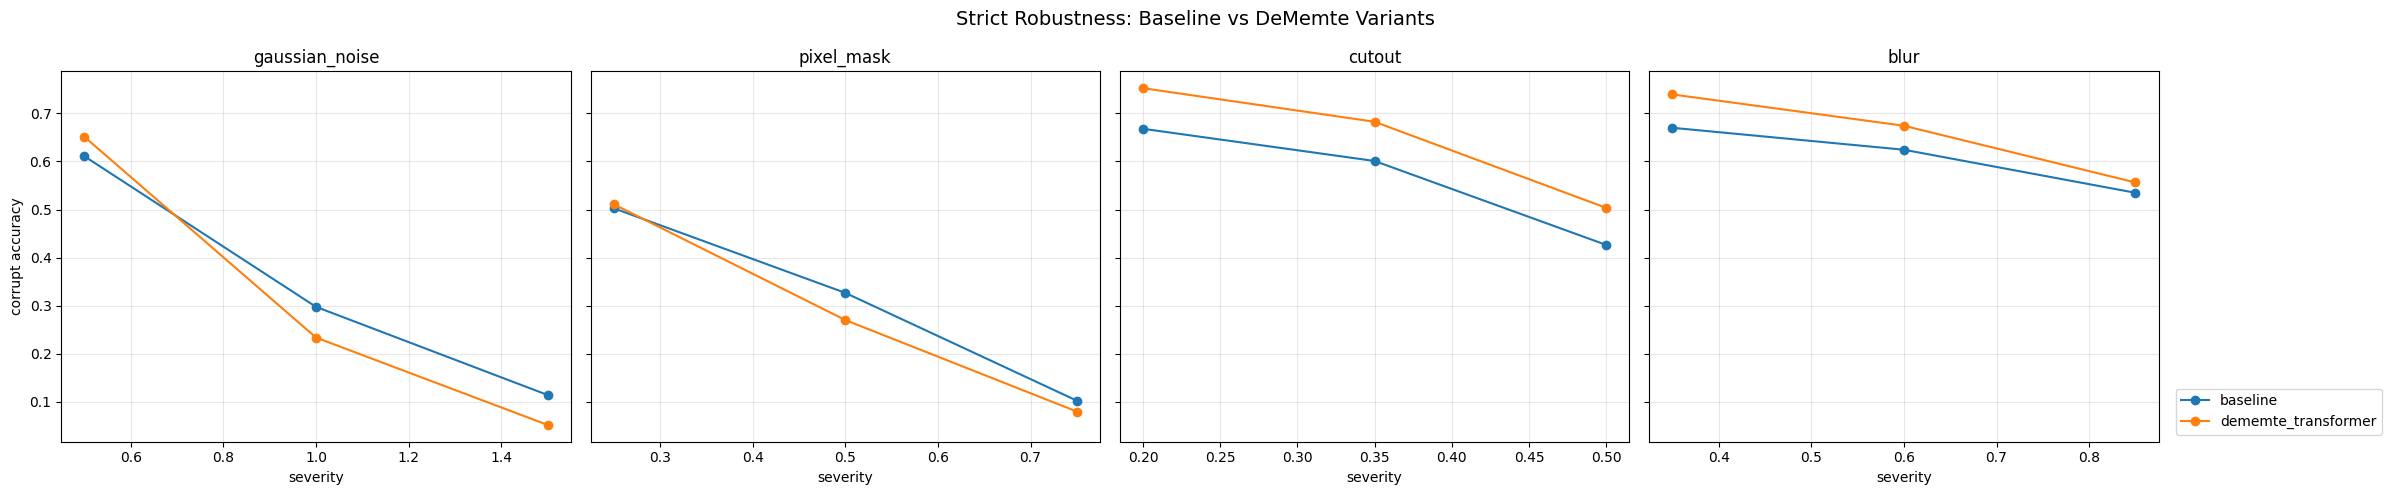

artifact dir: ./out/artifacts/dememte_transformer_fullrun_20260302_151937
summary: ./out/artifacts/dememte_transformer_fullrun_20260302_151937/dememte_variants_summary.json


In [55]:
# Visualización comparativa por corrupción
model_names = list(models_eval.keys())
fig, axs = plt.subplots(1, 4, figsize=(24, 5), sharey=True)
fig.suptitle('Strict Robustness: Baseline vs DeMemte Variants', fontsize=14)

for i, corr in enumerate(strict_suite.keys()):
    rows = [r for r in strict_results if r['corruption'] == corr]
    levels = [r['level'] for r in rows]

    for name in model_names:
        vals = [r[f'{name}_corrupt_acc'] for r in rows]
        axs[i].plot(levels, vals, marker='o', label=name)

    axs[i].set_title(corr)
    axs[i].set_xlabel('severity')
    axs[i].grid(alpha=0.3)

axs[0].set_ylabel('corrupt accuracy')
axs[-1].legend(loc='lower left', bbox_to_anchor=(1.02, 0.0))
plt.tight_layout()
plt.show()

summary = {
    'config': asdict(cfg),
    'clean_results': results,
    'strict_results': strict_results,
    'overall_corrupt_acc': overall,
    'best_variant': best_name,
}

summary_path = os.path.join(artifacts_dir, 'dememte_variants_summary.json')
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

for name in models_eval.keys():
    ckpt = {
        'name': name,
        'state_dict': models_eval[name].state_dict(),
        'config': asdict(cfg),
    }
    torch.save(ckpt, os.path.join(artifacts_dir, f'{name}_best.pt'))

print('artifact dir:', artifacts_dir)
print('summary:', summary_path)

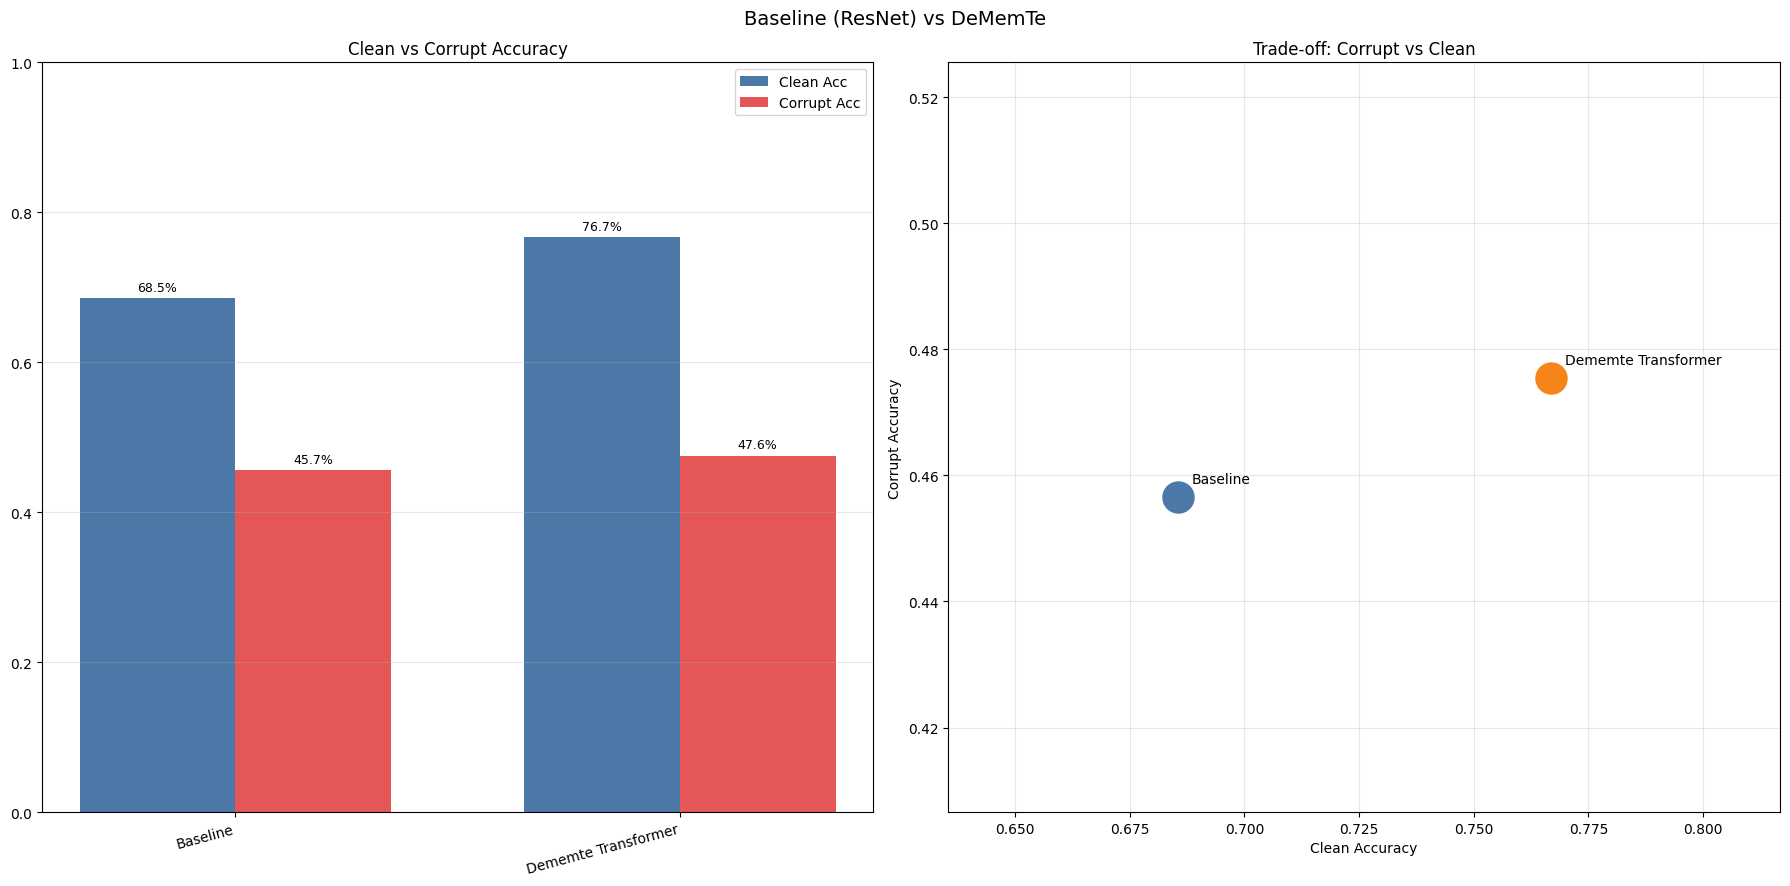

Resumen final de Robustez:
              baseline: Clean=0.6855  | Corrupt=0.4566  | Drop=0.2289
   dememte_transformer: Clean=0.7668  | Corrupt=0.4755  | Drop=0.2913


In [56]:
# Comparación final: Baseline ResNet puro vs variantes DeMemte
model_order = ['baseline'] + [k for k in variant_names]
labels = [m.replace('_', ' ').title() for m in model_order]

clean_test = []
for m in model_order:
    if m == 'baseline':
        clean_test.append(results['baseline']['test_clean_acc'])
    else:
        clean_test.append(results['variants'][m]['test_clean_acc'])

overall_corrupt = [overall[m] for m in model_order]
accuracy_drop = [c - n for c, n in zip(clean_test, overall_corrupt)]

x = np.arange(len(model_order))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
colors = ['#4c78a8', '#f58518', '#54a24b', '#e45756', '#54a24b', '#e45756'][:max(len(x), 6)]

def add_pct_labels(ax, bars):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f'{h*100:.1f}%',
            (bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, 3 if h >= 0 else -3),
            textcoords='offset points',
            ha='center',
            va='bottom' if h >= 0 else 'top',
            fontsize=9
        )

# 1) Barras agrupadas: Clean vs Corrupt
bars_clean = axes[0].bar(x - width/2, clean_test, width, label='Clean Acc', color='#4c78a8')
bars_corrupt = axes[0].bar(x + width/2, overall_corrupt, width, label='Corrupt Acc', color='#e45756')
add_pct_labels(axes[0], bars_clean)
add_pct_labels(axes[0], bars_corrupt)

axes[0].set_title('Clean vs Corrupt Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=15, ha='right')
axes[0].set_ylim(0.0, 1.0)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2) Trade-off Scatter Plot
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.7, label='x=y (No drop limit)')
for i, (m, c, n) in enumerate(zip(model_order, clean_test, overall_corrupt)):
    axes[1].scatter(c, n, s=500, color=colors[i], label=labels[i])
    axes[1].annotate(labels[i], (c, n), xytext=(10, 10), textcoords='offset points')
axes[1].set_title('Trade-off: Corrupt vs Clean')
axes[1].set_xlabel('Clean Accuracy')
axes[1].set_ylabel('Corrupt Accuracy')
axes[1].set_xlim(max(0, min(clean_test)-0.05), min(1, max(clean_test)+0.05))
axes[1].set_ylim(max(0, min(overall_corrupt)-0.05), min(1, max(overall_corrupt)+0.05))
axes[1].grid(alpha=0.3)


plt.suptitle('Baseline (ResNet) vs DeMemTe', fontsize=14)
plt.tight_layout()
plt.show()

print('Resumen final de Robustez:')
for m, c, n, d in zip(model_order, clean_test, overall_corrupt, accuracy_drop):
    print(f"  {m:>20}: Clean={c:.4f}  | Corrupt={n:.4f}  | Drop={d:.4f}")

===== COST PROFILE (TRAIN) =====
Profile batches: 40
Params (M) baseline=11.23 | transformer=13.48
Baseline epoch: 1.45s | 441.5 samples/s | peak_mem=1249.3 MB
Transformer P1 epoch: 1.47s | 435.8 samples/s | peak_mem=998.5 MB
Transformer P2 epoch: 1.44s | 443.9 samples/s | peak_mem=1071.8 MB
Estimated total time baseline: 0.24 min
Estimated total time transformer: 0.34 min
Slowdown transformer vs baseline: x1.40
Noisy gain: +1.90 pp
Extra minutes per +1pp noisy gain: 0.05 min/pp


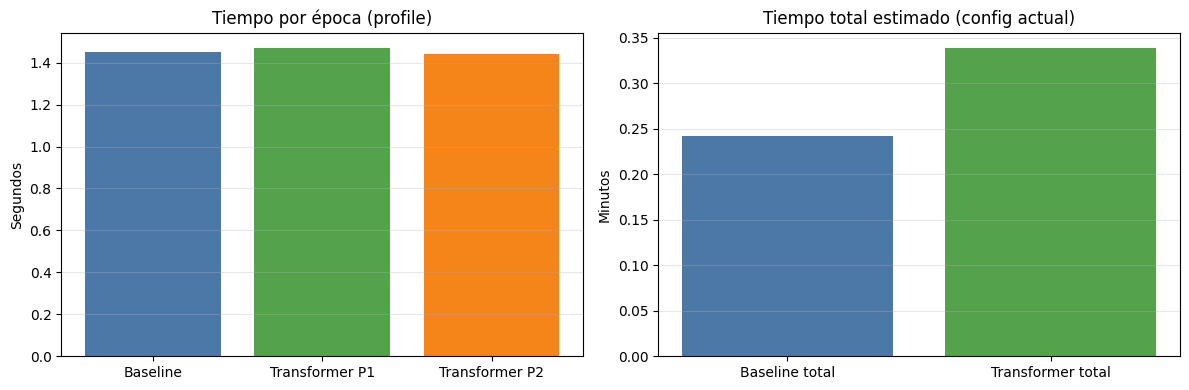

In [64]:
# Perfil de costo de entrenamiento: Baseline vs DeMemte Transformer
import time
import numpy as np
import matplotlib.pyplot as plt
import torch

profile_batches = 40
prev_max_train_batches = cfg.max_train_batches_debug
cfg.max_train_batches_debug = profile_batches

def _count_params_m(model):
    return sum(p.numel() for p in model.parameters()) / 1e6

def _peak_mem_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return 0.0

def _profile_epoch(fn, *args, **kwargs):
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    stats = fn(*args, **kwargs)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    dt = time.perf_counter() - t0
    n = stats.get('n', 0) if isinstance(stats, dict) else 0
    sps = (n / dt) if dt > 0 else float('nan')
    mem = _peak_mem_mb()
    return stats, dt, sps, mem

try:
    baseline_prof, b_opt_prof, _ = make_baseline(cfg)
    b_params = _count_params_m(baseline_prof)
    _, t_b, sps_b, mem_b = _profile_epoch(run_epoch_baseline, baseline_prof, trainloader, b_opt_prof, True)

    trans_prof, d_opt1_prof, _, d_opt2_prof, _ = make_variant(cfg, 'dememte_transformer')
    d_params = _count_params_m(trans_prof)
    _, t_p1, sps_p1, mem_p1 = _profile_epoch(run_epoch_variant_p1, trans_prof, trainloader, d_opt1_prof, True, 'dememte_transformer')
    _, t_p2, sps_p2, mem_p2 = _profile_epoch(run_epoch_variant_p2, trans_prof, trainloader, d_opt2_prof, True, 'dememte_transformer')
finally:
    cfg.max_train_batches_debug = prev_max_train_batches

baseline_total_min = (t_b * cfg.epochs_baseline_max) / 60.0
transformer_total_min = (t_p1 * cfg.epochs_phase1_max + t_p2 * cfg.epochs_phase2_max) / 60.0
slowdown = transformer_total_min / max(1e-8, baseline_total_min)

noisy_gain_pp = (overall['dememte_transformer'] - overall['baseline']) * 100.0
extra_min = transformer_total_min - baseline_total_min
min_per_pp = (extra_min / noisy_gain_pp) if noisy_gain_pp > 0 else float('inf')

print('===== COST PROFILE (TRAIN) =====')
print(f'Profile batches: {profile_batches}')
print(f'Params (M) baseline={b_params:.2f} | transformer={d_params:.2f}')
print(f'Baseline epoch: {t_b:.2f}s | {sps_b:.1f} samples/s | peak_mem={mem_b:.1f} MB')
print(f'Transformer P1 epoch: {t_p1:.2f}s | {sps_p1:.1f} samples/s | peak_mem={mem_p1:.1f} MB')
print(f'Transformer P2 epoch: {t_p2:.2f}s | {sps_p2:.1f} samples/s | peak_mem={mem_p2:.1f} MB')
print(f'Estimated total time baseline: {baseline_total_min:.2f} min')
print(f'Estimated total time transformer: {transformer_total_min:.2f} min')
print(f'Slowdown transformer vs baseline: x{slowdown:.2f}')
print(f'Noisy gain: {noisy_gain_pp:+.2f} pp')
if np.isfinite(min_per_pp):
    print(f'Extra minutes per +1pp noisy gain: {min_per_pp:.2f} min/pp')
else:
    print('Extra minutes per +1pp noisy gain: N/A (ganancia <= 0)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Baseline', 'Transformer P1', 'Transformer P2'], [t_b, t_p1, t_p2], color=['#4c78a8', '#54a24b', '#f58518'])
axes[0].set_title('Tiempo por época (profile)')
axes[0].set_ylabel('Segundos')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(['Baseline total', 'Transformer total'], [baseline_total_min, transformer_total_min], color=['#4c78a8', '#54a24b'])
axes[1].set_title('Tiempo total estimado (config actual)')
axes[1].set_ylabel('Minutos')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()